# Assignment 2

## Overview

This assignment builds upon the classification task established in Assignment 1, replacing traditional machine learning pipelines with pre-trained transformer models sourced from the Hugging Face Hub. The goal is to fine-tune a suitable pre-trained model on the same dataset and evaluate whether transformer-based approaches yield meaningful improvements over the best-performing classical models from Assignment 1.

Assignment 1 established a strong baseline using a diverse set of feature representations (TF-IDF, BoW, Hashing, LSA, Word2Vec, FastText, linguistic features, n-grams) combined with classifiers such as Logistic Regression, SVM, XGBoost, AdaBoost, Naive Bayes, and k-NN. The top result was **Logistic Regression + TF-IDF**, achieving an F1 score of **0.6289**. This serves as the primary benchmark for the models developed here.

## 1. Setup

In [32]:
# !pip install transformers datasets evaluate accelerate torch -q

import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import chain
import os

from sklearn.metrics import (
    classification_report,
    f1_score,
)
from datasets import Dataset, DatasetDict, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
    AutoModelForMaskedLM,
    DataCollatorForLanguageModeling,
    pipeline,
)
import evaluate

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {DEVICE}")

Using device: cuda


## 2. Dataset

The dataset used here is identical to Assignment 1: the ADS509/full_experiment_labels dataset from the Hugging Face Hub, consisting of social media comments on political discourse collected from YouTube, Hacker News, MetaFilter, Reddit, and BlueSky between 2024 and mid-February 2026.

The classification task involves five classes:

- **Neutral (0):** Clarifying questions, meta-commentary, or off-topic remarks.
- **Opinion (1):** Value judgments or stances without substantial reasoning.
- **Argumentative (2):** Specific claims or assertions supported by reasoning, evidence, or anecdotes aiming to persuade.
- **Expressive (3):** Emotional reactions, sarcasm, venting, or performative agreement/disagreement.
- **Informational (4):** Sharing facts, data, links, or context with low emotional affect.

The dataset totals 70,383 examples across the standard splits:

- Training Set: 49,268 examples
- Validation Set: 10,557 examples
- Testing Set: 10,558 examples

No additional preprocessing is applied on top of what the dataset creators already performed (emoji-to-text conversion, lowercasing, HTML stripping, URL replacement, and duplicate/NaN removal), as transformer tokenizers are designed to operate directly on clean raw text.

Train: 49,268 | Val: 10,557 | Test: 10,558


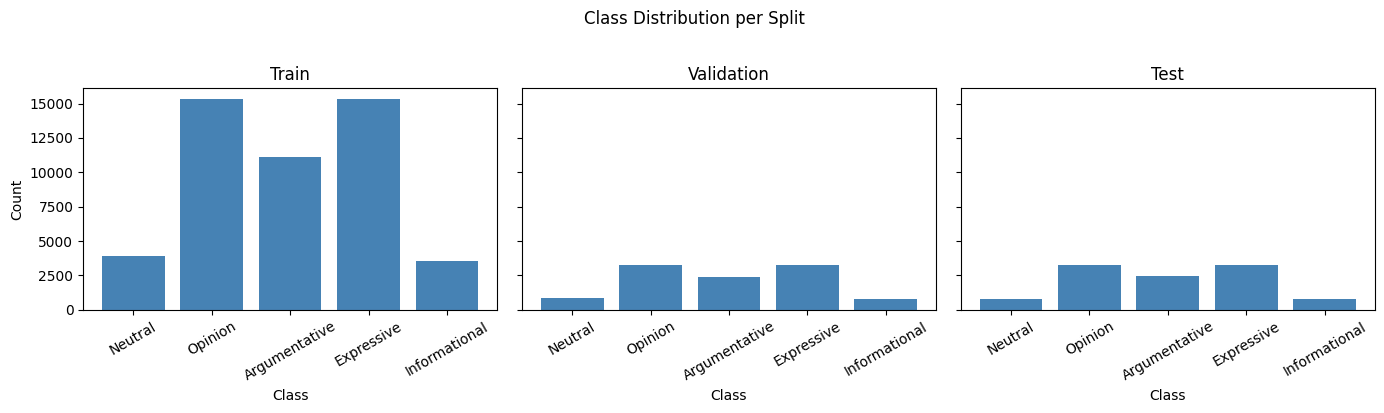


Word count statistics (train):
count    49268.0
mean        32.8
std         53.8
min          1.0
25%          9.0
50%         17.0
75%         36.0
max       2162.0
Name: word_count, dtype: float64
  p75 = 36 words
  p90 = 69 words
  p95 = 112 words


In [33]:
DATA_DIR = Path("../data")

train_df = pd.read_csv(DATA_DIR / "train_data.csv")
val_df   = pd.read_csv(DATA_DIR / "valid_data.csv")
test_df  = pd.read_csv(DATA_DIR / "test_data.csv")

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

ID2LABEL = {0: "Neutral", 1: "Opinion", 2: "Argumentative", 3: "Expressive", 4: "Informational"}

# Class distribution across splits
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (df, split) in zip(axes, [(train_df, "Train"), (val_df, "Validation"), (test_df, "Test")]):
    counts = df["label"].value_counts().sort_index()
    ax.bar([ID2LABEL[i] for i in counts.index], counts.values, color="steelblue")
    ax.set_title(split)
    ax.set_xlabel("Class")
    ax.tick_params(axis='x', rotation=30)
axes[0].set_ylabel("Count")
plt.suptitle("Class Distribution per Split", y=1.02)
plt.tight_layout()
plt.show()

# Text length distribution (word-level proxy for token count)
train_df["word_count"] = train_df["text"].str.split().str.len()
print("\nWord count statistics (train):")
print(train_df["word_count"].describe().round(1))
for q in [0.75, 0.90, 0.95]:
    print(f"  p{int(q*100)} = {train_df['word_count'].quantile(q):.0f} words")

## 3. Model Selection

The dataset consists of English social media text with informal language, political references, sarcasm, and emotional expression. This genre calls for a model pre-trained on large-scale English web or social media corpora, rather than a domain-specific or multilingual model.

The model used is **`distilroberta-base`**, a distilled version of RoBERTa-base produced via knowledge distillation: a smaller 6-layer student model is trained to reproduce the output distributions of the 12-layer RoBERTa-base teacher. This yields a model that retains ~95% of RoBERTa's performance on GLUE benchmarks while being approximately 2× faster and using half the memory — a practical trade-off given the dataset size (~50K examples) and available compute.

Compared to `bert-base-uncased`, RoBERTa-family models consistently outperform on downstream classification tasks and handle informal and varied text more robustly, making `distilroberta-base` a natural fit for this dataset's mix of platforms and writing styles.

Fine-tuning will be performed using the Hugging Face `transformers` library with a sequence classification head added on top of the pre-trained encoder.

## 4. Tokenization & Dataset Preparation

RoBERTa uses a BPE tokenizer. The training set has a median of ~17 words and a 90th percentile of ~69 words, so `max_length=128` is used as a hard truncation ceiling — comfortably covering ~95% of examples (p95 ≈ 112 words).

Rather than padding every sequence to exactly 128 tokens at preprocessing time (`padding="max_length"`), sequences are stored at their natural length and a `DataCollatorWithPadding` is used to pad each batch only to the length of its longest sequence. Because most examples are short (~17 words), this significantly reduces the number of padding tokens the model processes per step, speeding up training without any loss of information.

In [34]:
MODEL_NAME = "distilroberta-base"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def df_to_hf(df):
    return Dataset.from_dict({"text": df["text"].tolist(), "label": df["label"].tolist()})

raw_datasets = DatasetDict({
    "train":      df_to_hf(train_df),
    "validation": df_to_hf(val_df),
    "test":       df_to_hf(test_df),
})

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized_datasets = raw_datasets.map(tokenize, batched=True, remove_columns=["text"])
tokenized_datasets.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(tokenized_datasets)
print("\nSample keys:", list(tokenized_datasets["train"][0].keys()))

Map: 100%|██████████| 10558/10558 [00:00<00:00, 22940.97 examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 49268
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 10557
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 10558
    })
})

Sample keys: ['label', 'input_ids', 'attention_mask']


## 5. Model Instantiation

A linear classification head with 5 output units is attached on top of the pre-trained RoBERTa encoder. The head weights are randomly initialised; all parameters (encoder + head) are updated during fine-tuning.

In [35]:
LABEL2ID = {v: k for k, v in ID2LABEL.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loading weights: 100%|██████████| 101/101 [00:00<00:00, 2922.32it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     82,122,245
Trainable parameters: 82,122,245


## 6. Training Configuration

Two additional decisions beyond the standard `TrainingArguments`:

**Class weights** — labels 0 (Neutral) and 4 (Informational) each have roughly 3–4× fewer examples than labels 1 and 3. Without correction, the model optimises accuracy on majority classes at the cost of macro F1. Inverse-frequency weights are passed to `CrossEntropyLoss` via a custom `Trainer` subclass.

**Early stopping** — training is halted if validation macro F1 does not improve for 2 consecutive epochs, preventing overfitting on the smaller minority classes.

In [36]:
# Inverse-frequency class weights
label_counts = train_df["label"].value_counts().sort_index()
total_samples = label_counts.sum()
class_weights = torch.tensor(
    [total_samples / (5 * label_counts[i]) for i in range(5)],
    dtype=torch.float,
).to(DEVICE)
print("Class weights:", {ID2LABEL[i]: round(w.item(), 3) for i, w in enumerate(class_weights)})

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = torch.nn.functional.cross_entropy(
            outputs.logits, labels, weight=class_weights
        )
        return (loss, outputs) if return_outputs else loss

# Evaluation metrics
metric_f1  = evaluate.load("f1")
metric_acc = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    f1  = metric_f1.compute(predictions=preds, references=labels, average="macro")["f1"]
    acc = metric_acc.compute(predictions=preds, references=labels)["accuracy"]
    return {"f1": f1, "accuracy": acc}

OUTPUT_DIR = "../models/distilroberta-base-finetuned"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    greater_is_better=True,
    logging_steps=100,
    seed=SEED,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    data_collator=data_collator,
)

Class weights: {'Neutral': 2.495, 'Opinion': 0.642, 'Argumentative': 0.886, 'Expressive': 0.643, 'Informational': 2.798}


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


## 7. Fine-tuning

The `WeightedTrainer` configured in Section 6 is run for up to 5 epochs with a learning rate of 2e-5, a linear warmup over the first 10% of steps, and weight decay of 0.01. Validation macro F1 is evaluated at the end of each epoch; the best checkpoint is automatically reloaded at the end of training via `load_best_model_at_end=True`, and early stopping halts training if no improvement is seen for 2 consecutive epochs.

The trained model is saved to disk so that subsequent runs can reload it directly without retraining (`FORCE_RETRAIN = False`). Learning curves (training loss per step, validation loss and macro F1 per epoch) are plotted when training runs.

Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.738448,0.708439,0.678271,0.693568
2,0.623882,0.690857,0.714536,0.729469
3,0.530068,0.697415,0.718242,0.730321
4,0.431374,0.805599,0.722560,0.737047
5,0.343277,0.823284,0.722454,0.734489


Writing model shards: 100%|██████████| 1/1 [00:05<00:00,  5.87s/it]


Model saved to '../models/distilroberta-base-finetuned/best'


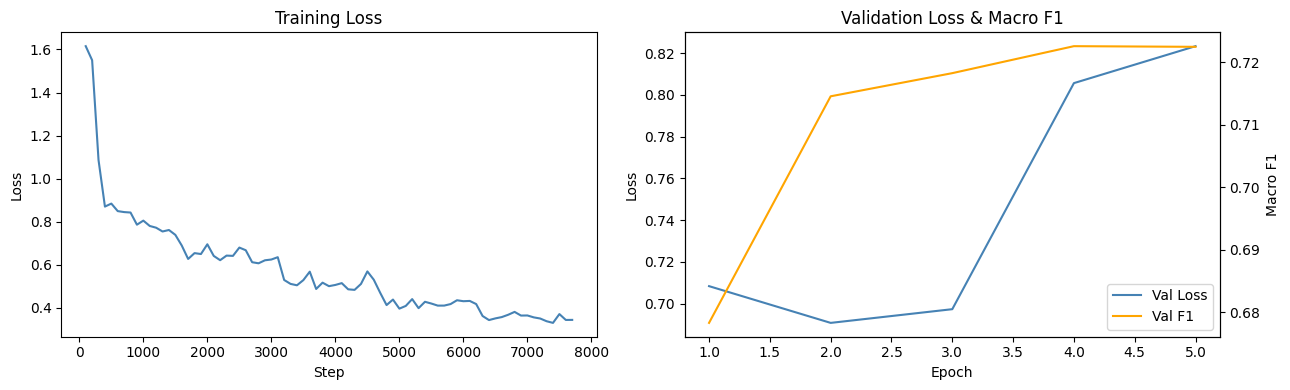


Best val Macro F1: 0.7226 (epoch 4)


In [37]:
import os

BEST_MODEL_DIR = OUTPUT_DIR + "/best"
FORCE_RETRAIN = False  # set to True to ignore saved model and retrain

if not FORCE_RETRAIN and os.path.exists(BEST_MODEL_DIR):
    print(f"Saved model found at '{BEST_MODEL_DIR}' — skipping training.")
    model = AutoModelForSequenceClassification.from_pretrained(BEST_MODEL_DIR)
    model.to(DEVICE)
    trainer.model = model
    log_df = pd.DataFrame()
    val_logs = pd.DataFrame()
else:
    train_result = trainer.train()

    # Save best model so future runs skip training
    trainer.save_model(BEST_MODEL_DIR)
    tokenizer.save_pretrained(BEST_MODEL_DIR)
    print(f"Model saved to '{BEST_MODEL_DIR}'")

    # Learning curves
    log_df     = pd.DataFrame(trainer.state.log_history)
    train_logs = log_df[log_df["loss"].notna()][["step", "loss"]]
    val_logs   = log_df[log_df["eval_loss"].notna()][["epoch", "eval_loss", "eval_f1", "eval_accuracy"]]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(train_logs["step"], train_logs["loss"], color="steelblue")
    ax1.set(xlabel="Step", ylabel="Loss", title="Training Loss")

    ax2.plot(val_logs["epoch"], val_logs["eval_loss"], color="steelblue", label="Val Loss")
    ax2.set(xlabel="Epoch", ylabel="Loss", title="Validation Loss & Macro F1")
    ax2r = ax2.twinx()
    ax2r.plot(val_logs["epoch"], val_logs["eval_f1"], color="orange", label="Val F1")
    ax2r.set_ylabel("Macro F1")
    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2r.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

    plt.tight_layout()
    plt.show()

    print(f"\nBest val Macro F1: {val_logs['eval_f1'].max():.4f} (epoch {val_logs.loc[val_logs['eval_f1'].idxmax(), 'epoch']:.0f})")

## 8. Evaluation on Validation Set

Per-class metrics reveal which discourse types the model finds hardest. We expect the boundary between **Opinion** and **Argumentative** to be the primary confusion pair, as both express stances — Opinion lacks explicit supporting reasoning while Argumentative includes it, a distinction that is often subtle in short text.

Validation Set — Classification Report
               precision    recall  f1-score   support

      Neutral     0.6814    0.7007    0.6909       882
      Opinion     0.7098    0.6798    0.6945      3257
Argumentative     0.7514    0.7878    0.7692      2394
   Expressive     0.8073    0.7646    0.7854      3254
Informational     0.6124    0.7468    0.6729       770

     accuracy                         0.7370     10557
    macro avg     0.7124    0.7359    0.7226     10557
 weighted avg     0.7398    0.7370    0.7376     10557



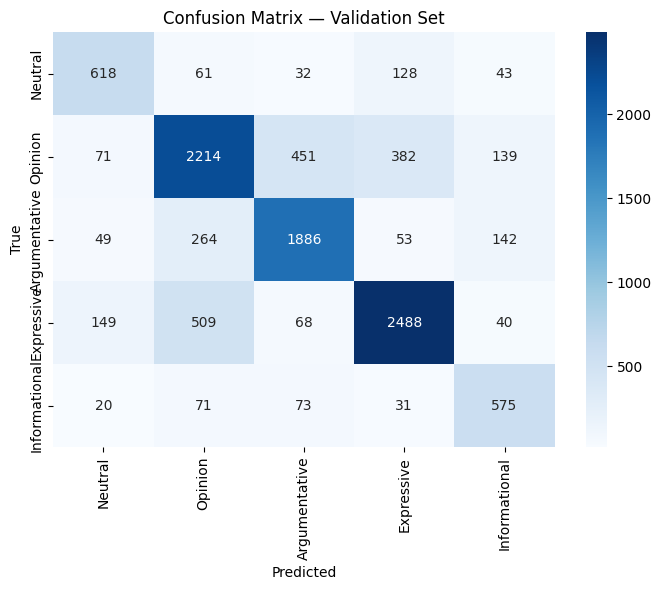

In [38]:
from sklearn.metrics import classification_report, confusion_matrix

val_out    = trainer.predict(tokenized_datasets["validation"])
val_preds  = np.argmax(val_out.predictions, axis=-1)
val_labels = val_out.label_ids

print("Validation Set — Classification Report")
print(classification_report(val_labels, val_preds, target_names=list(ID2LABEL.values()), digits=4))

cm_val = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_val, annot=True, fmt="d", cmap="Blues",
    xticklabels=list(ID2LABEL.values()),
    yticklabels=list(ID2LABEL.values()),
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Validation Set")
plt.tight_layout()
plt.show()

## 9. Test Set Evaluation

The test set is evaluated only once — after the best checkpoint has been selected based on validation F1 — to avoid any implicit optimisation on the test distribution.

In [39]:
test_out    = trainer.predict(tokenized_datasets["test"])
test_preds  = np.argmax(test_out.predictions, axis=-1)
test_labels = test_out.label_ids

test_f1  = metric_f1.compute(predictions=test_preds, references=test_labels, average="macro")["f1"]
test_acc = metric_acc.compute(predictions=test_preds, references=test_labels)["accuracy"]
print(f"[Full Fine-tune] Test Macro F1: {test_f1:.4f} | Accuracy: {test_acc:.4f}")

[Full Fine-tune] Test Macro F1: 0.7254 | Accuracy: 0.7424


## 10. Error Analysis

We examine which class pairs the model confuses most often, inspect representative misclassified examples, and check whether prediction accuracy degrades for longer texts that were partially truncated.

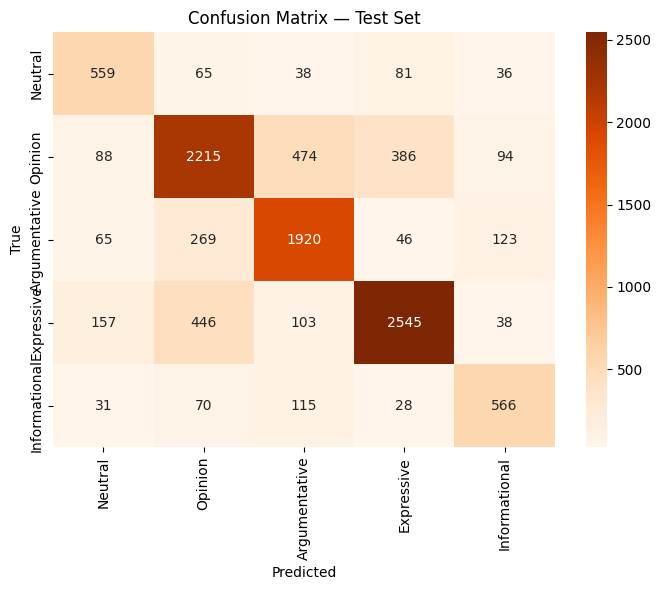

Top confused class pairs:
   true_label    pred_label  count
      Opinion Argumentative    474
   Expressive       Opinion    446
      Opinion    Expressive    386
Argumentative       Opinion    269
   Expressive       Neutral    157
Argumentative Informational    123
Informational Argumentative    115
   Expressive Argumentative    103
      Opinion Informational     94
      Opinion       Neutral     88

Sample errors — true: Opinion → predicted: Argumentative
  [27 words] it’s already not america, and though i’m not a fan of elon, his good efforts were thwarted at doge… many lost their jobs for 100% accurate reasons.
  [35 words] so that would undermine a key aspect of their message that illegals are jobless and abusing the social systems. you know, the more they talk, the more
  [34 words] > how did the author decide which part to present as plain fact, and which as mere activist opinion?they have a very obvious bias, and the parts suppo
  [50 words] with facebook algorithms i ge

In [9]:
# Build evaluation dataframe
eval_df = test_df.copy().reset_index(drop=True)
eval_df["pred"]    = test_preds
eval_df["true"]    = test_labels
eval_df["correct"] = eval_df["pred"] == eval_df["true"]
eval_df["word_count"] = eval_df["text"].str.split().str.len()

# Confusion matrix — test set
cm_test = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_test, annot=True, fmt="d", cmap="Oranges",
    xticklabels=list(ID2LABEL.values()),
    yticklabels=list(ID2LABEL.values()),
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

# Top confused class pairs
errors = eval_df[~eval_df["correct"]]
pair_counts = (
    errors.groupby(["true", "pred"]).size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
pair_counts["true_label"] = pair_counts["true"].map(ID2LABEL)
pair_counts["pred_label"] = pair_counts["pred"].map(ID2LABEL)
print("Top confused class pairs:")
print(pair_counts[["true_label", "pred_label", "count"]].head(10).to_string(index=False))

# Sample misclassified examples for the most confused pair
top_true = pair_counts.iloc[0]["true"]
top_pred = pair_counts.iloc[0]["pred"]
samples  = errors[(errors["true"] == top_true) & (errors["pred"] == top_pred)].sample(
    min(5, len(errors)), random_state=SEED
)
print(f"\nSample errors — true: {ID2LABEL[top_true]} → predicted: {ID2LABEL[top_pred]}")
for _, row in samples.iterrows():
    print(f"  [{row['word_count']} words] {row['text'][:150]}")

# Accuracy by text length bucket
eval_df["length_bucket"] = pd.cut(
    eval_df["word_count"],
    bins=[0, 10, 30, 60, 128, 9999],
    labels=["1–10", "11–30", "31–60", "61–128", "128+"],
)
acc_by_len = eval_df.groupby("length_bucket", observed=True)["correct"].mean().rename("accuracy")
count_by_len = eval_df.groupby("length_bucket", observed=True)["correct"].count().rename("n")
print("\nAccuracy by text length (word count):")
print(pd.concat([count_by_len, acc_by_len.round(4)], axis=1).to_string())

## 11. Domain Adaptation via Masked Language Modeling (MLM Pre-training)

Following the approach from the HuggingFace course (Chapter 7.3), domain adaptation
consists of continuing the MLM pre-training of distilroberta-base on our own corpus
*before* fine-tuning it for classification. No labels are required for this step —
the model learns the statistical patterns of social-media political discourse in a
self-supervised manner, which should help it handle the informal language, sarcasm,
and political vocabulary of our dataset better than a model pre-trained on generic
English web text.

Pipeline:
1. Tokenise all text (no truncation) and concatenate into fixed-size chunks.
2. Apply DataCollatorForLanguageModeling (15 % random masking) at batch time.
3. Train with AutoModelForMaskedLM for a small number of steps/epochs.
4. Save the adapted encoder, then attach a fresh classification head and fine-tune exactly as in Sections 5–9.
5. Compare test F1 against the vanilla distilroberta-base fine-tune.

### 11.1 Tokenise corpus for MLM (no truncation, no padding)

In [5]:
MLM_MODEL_NAME = "distilroberta-base"
CHUNK_SIZE     = 128
MLM_OUTPUT_DIR = "../models/distilroberta-base-domain-adapted"

mlm_tokenizer = AutoTokenizer.from_pretrained(MLM_MODEL_NAME)

# Combine only train and val splits to prevent test set data leakage
all_texts = pd.concat([train_df, val_df])["text"].dropna().tolist()
mlm_raw   = Dataset.from_dict({"text": all_texts})

def tokenize_for_mlm(batch):
    # No truncation — we will rechunk manually
    return mlm_tokenizer(batch["text"], truncation=False)

mlm_tokenized = mlm_raw.map(
    tokenize_for_mlm,
    batched=True,
    remove_columns=["text"],
)
print(f"Tokenised corpus: {len(mlm_tokenized):,} examples (variable length)")

Map: 100%|██████████| 59825/59825 [00:03<00:00, 18778.84 examples/s]

Tokenised corpus: 59,825 examples (variable length)


### 11.2  Chunk into fixed-size blocks

In [6]:
def group_texts(examples):
    # Flatten lists efficiently using itertools.chain to prevent O(N^2) memory spikes
    concatenated = {k: list(chain(*examples[k])) for k in examples.keys()}
    total = len(concatenated[list(examples.keys())[0]])
    total = (total // CHUNK_SIZE) * CHUNK_SIZE          # drop last partial chunk

    result = {
        k: [t[i : i + CHUNK_SIZE] for i in range(0, total, CHUNK_SIZE)]
        for k, t in concatenated.items()
    }
    result["labels"] = result["input_ids"].copy()       # MLM target = original ids
    return result

mlm_chunked = mlm_tokenized.map(group_texts, batched=True)
mlm_chunked = mlm_chunked.train_test_split(test_size=0.05, seed=SEED)

print(mlm_chunked)
print(f"\nEach example is exactly {CHUNK_SIZE} tokens.")

Map: 100%|██████████| 59825/59825 [00:02<00:00, 20295.06 examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 20460
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1077
    })
})

Each example is exactly 128 tokens.


### 11.3  Data collator for masked language modelling
DataCollatorForLanguageModeling randomly masks 15 % of tokens at batch time and sets their labels so the model has to predict the original token.

In [8]:
mlm_data_collator = DataCollatorForLanguageModeling(
    tokenizer=mlm_tokenizer,
    mlm=True,
    mlm_probability=0.15,
)

# Quick sanity check: show one masked batch
import torch
sample_batch = mlm_data_collator([mlm_chunked["train"][i] for i in range(4)])
print("input_ids  :", sample_batch["input_ids"][0][:20].tolist())
print("labels     :", sample_batch["labels"][0][:20].tolist())  # -100 = not masked

input_ids  : [162, 1025, 2, 0, 424, 50264, 328, 3392, 47, 13, 3565, 50264, 505, 335, 2, 0, 2028, 811, 10, 625]
labels     : [-100, -100, -100, -100, -100, 22736, -100, -100, -100, -100, -100, 42, -100, -100, -100, -100, -100, -100, -100, -100]


### 11.4  MLM pre-training (domain adaptation)

In [9]:
FORCE_RETRAIN_MLM = False

if not FORCE_RETRAIN_MLM and os.path.exists(MLM_OUTPUT_DIR):
    print(f"Domain-adapted model found at '{MLM_OUTPUT_DIR}' — skipping MLM training.")
else:
    mlm_model = AutoModelForMaskedLM.from_pretrained(MLM_MODEL_NAME)
    
    mlm_training_args = TrainingArguments(
        output_dir=MLM_OUTPUT_DIR,
        num_train_epochs=3,                    
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_ratio=0.06,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,                    
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        logging_steps=200,
        seed=SEED,
        report_to="none",
    )
    
    mlm_trainer = Trainer(
        model=mlm_model,
        args=mlm_training_args,
        train_dataset=mlm_chunked["train"],
        eval_dataset=mlm_chunked["test"],
        data_collator=mlm_data_collator,
    )
    
    mlm_trainer.train()
    mlm_trainer.save_model(MLM_OUTPUT_DIR)
    mlm_tokenizer.save_pretrained(MLM_OUTPUT_DIR)
    print(f"Domain-adapted encoder saved to '{MLM_OUTPUT_DIR}'")

Loading weights: 100%|██████████| 106/106 [00:00<00:00, 3470.26it/s]
[transformers] RobertaForMaskedLM LOAD REPORT from: distilroberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss
1,2.644125,2.455325
2,2.576581,2.391280
3,2.506346,2.382592


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.92s/it]
[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.decoder.weight', 'lm_head.decoder.bias'].
Writing model shards: 100%|██████████| 1/1 [00:05<00:00,  5.26s/it]

Domain-adapted encoder saved to '../models/distilroberta-base-domain-adapted'


### 11.5  Qualitative check: fill-mask before vs after adaptation

In [13]:
probe = "The politician's <mask> was widely criticised on social media."

base_fill  = pipeline("fill-mask", model=MLM_MODEL_NAME, tokenizer=MLM_MODEL_NAME)
adapted_fill = pipeline("fill-mask", model=MLM_OUTPUT_DIR, tokenizer=MLM_OUTPUT_DIR)

print("── Base model predictions ──")
for r in base_fill(probe)[:5]:
    print(f"  {r['token_str']:<20}  score={r['score']:.4f}")

print("\n── Domain-adapted predictions ──")
for r in adapted_fill(probe)[:5]:
    print(f"  {r['token_str']:<20}  score={r['score']:.4f}")

Loading weights: 100%|██████████| 106/106 [00:00<00:00, 2549.10it/s]
[transformers] RobertaForMaskedLM LOAD REPORT from: distilroberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 106/106 [00:00<00:00, 3925.90it/s]


── Base model predictions ──
   behaviour            score=0.1015
   remark               score=0.0943
   speech               score=0.0462
   comment              score=0.0377
   comments             score=0.0315

── Domain-adapted predictions ──
   comment              score=0.0950
   behaviour            score=0.0791
   remark               score=0.0471
   speech               score=0.0438
   performance          score=0.0292


## 12.  Full Fine-tune on Domain-Adapted Model

In [47]:
MAX_LENGTH = 128
LABEL2ID = {v: k for k, v in ID2LABEL.items()}

label_counts = train_df["label"].value_counts().sort_index()
total_samples = label_counts.sum()
class_weights = torch.tensor(
    [total_samples / (5 * label_counts[i]) for i in range(5)],
    dtype=torch.float,
).to(DEVICE)

metric_f1  = evaluate.load("f1")
metric_acc = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    f1  = metric_f1.compute(predictions=preds, references=labels, average="macro")["f1"]
    acc = metric_acc.compute(predictions=preds, references=labels)["accuracy"]
    return {"f1": f1, "accuracy": acc}

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = torch.nn.functional.cross_entropy(
            outputs.logits, labels, weight=class_weights
        )
        return (loss, outputs) if return_outputs else loss


DA_FINETUNE_DIR = "../models/distilroberta-domain-adapted-finetuned"
DA_BEST_DIR     = DA_FINETUNE_DIR + "/best"

MAX_LENGTH    = 128
da_tokenizer  = AutoTokenizer.from_pretrained(MLM_OUTPUT_DIR)
da_collator   = DataCollatorWithPadding(tokenizer=da_tokenizer)

def tokenize_da(batch):
    return da_tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

da_raw_datasets = DatasetDict({
    "train":      Dataset.from_dict({"text": train_df["text"].tolist(), "label": train_df["label"].tolist()}),
    "validation": Dataset.from_dict({"text": val_df["text"].tolist(),   "label": val_df["label"].tolist()}),
    "test":       Dataset.from_dict({"text": test_df["text"].tolist(),  "label": test_df["label"].tolist()}),
})

da_tokenized = da_raw_datasets.map(tokenize_da, batched=True, remove_columns=["text"])
da_tokenized.set_format("torch")


FORCE_RETRAIN_DA = False

if not FORCE_RETRAIN_DA and os.path.exists(DA_BEST_DIR):
    print(f"Saved domain-adapted fine-tuned model found — skipping training.")
else:
    da_model = AutoModelForSequenceClassification.from_pretrained(
        MLM_OUTPUT_DIR,
        num_labels=5,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
        ignore_mismatched_sizes=True,
    )

    da_training_args = TrainingArguments(
        output_dir=DA_FINETUNE_DIR,
        num_train_epochs=5,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_ratio=0.1,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_f1",
        greater_is_better=True,
        logging_steps=100,
        seed=SEED,
        report_to="none",
    )

    da_trainer = WeightedTrainer(
        model=da_model,
        args=da_training_args,
        train_dataset=da_tokenized["train"],
        eval_dataset=da_tokenized["validation"],
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
        data_collator=da_collator,
    )

    da_trainer.train()
    da_trainer.save_model(DA_BEST_DIR)  # saves the best model (load_best_model_at_end already loaded it)
    da_tokenizer.save_pretrained(DA_BEST_DIR)
    print(f"Domain-adapted fine-tuned model saved to '{DA_BEST_DIR}'")

# Always reload from DA_BEST_DIR to guarantee we use the best checkpoint
da_model = AutoModelForSequenceClassification.from_pretrained(DA_BEST_DIR)
da_model.to(DEVICE)

Map: 100%|██████████| 10558/10558 [00:00<00:00, 16600.79 examples/s]


Saved domain-adapted fine-tuned model found — skipping training.


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 2687.61it/s]


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
    

### 12.1  Evaluate on test set

In [48]:
da_trainer_eval = WeightedTrainer(
    model=da_model,
    args=TrainingArguments(output_dir="/tmp/da_eval", report_to="none"),
    data_collator=da_collator,
    compute_metrics=compute_metrics,
)

da_test_out    = da_trainer_eval.predict(da_tokenized["test"])
da_test_preds  = np.argmax(da_test_out.predictions, axis=-1)
da_test_labels = da_test_out.label_ids

da_f1  = metric_f1.compute(predictions=da_test_preds, references=da_test_labels, average="macro")["f1"]
da_acc = metric_acc.compute(predictions=da_test_preds, references=da_test_labels)["accuracy"]

print(f"Domain-Adapted Test Macro F1:  {da_f1:.4f}")
print(f"Domain-Adapted Test Accuracy:  {da_acc:.4f}")

print("\nClassification Report — Domain-Adapted (Test Set)")
print(classification_report(da_test_labels, da_test_preds, target_names=list(ID2LABEL.values()), digits=4))

Domain-Adapted Test Macro F1:  0.7250
Domain-Adapted Test Accuracy:  0.7411

Classification Report — Domain-Adapted (Test Set)
               precision    recall  f1-score   support

      Neutral     0.6142    0.7458    0.6736       779
      Opinion     0.7230    0.6835    0.7027      3257
Argumentative     0.7333    0.7965    0.7636      2423
   Expressive     0.8296    0.7607    0.7937      3289
Informational     0.6621    0.7235    0.6914       810

     accuracy                         0.7411     10558
    macro avg     0.7124    0.7420    0.7250     10558
 weighted avg     0.7458    0.7411    0.7420     10558



## 13. LoRA Fine-tune on Domain-Adapted Model

**LoRA (Low-Rank Adaptation)** is a parameter-efficient fine-tuning technique that freezes all pre-trained weights and injects small trainable rank-decomposition matrices into the attention layers. Instead of updating all 82 M parameters, only the added adapter matrices are trained — typically < 1 % of the original parameter count — while the frozen encoder acts as a fixed feature extractor with task-specific "steering" applied at each attention head.

Formally, for a weight matrix **W₀ ∈ ℝ^(d×k)**, LoRA adds:

> **W = W₀ + BA**, where **B ∈ ℝ^(d×r)**, **A ∈ ℝ^(r×k)**, rank *r* ≪ min(d, k)

During training only **A** and **B** are updated. At inference the product **BA** can be merged into **W₀** at zero extra latency.

**Configuration choices:**
- **Target modules:** `query` and `value` projections in every self-attention layer. These carry the most task-relevant signal and are the standard targets in the literature (Hu et al., 2021).
- **Rank r = 16:** Low enough to be parameter-efficient; high enough not to underfit a 5-class task on ~50 K examples.
- **Alpha = 32:** Scaling factor (α/r = 2) keeps effective learning rate in a stable range.
- **Dropout = 0.1:** Regularises the adapters, matching the encoder's own dropout rate.

The same weighted cross-entropy loss and early stopping strategy from Section 6 are reused unchanged.

### 13.1 Model Setup

In [41]:
from peft import LoraConfig, TaskType, get_peft_model, PeftModel

DA_LORA_OUTPUT_DIR = "../models/distilroberta-domain-adapted-lora"
DA_LORA_BEST_DIR   = DA_LORA_OUTPUT_DIR + "/best"

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["query", "value"],
    bias="none",
)

base_for_lora = AutoModelForSequenceClassification.from_pretrained(
    MLM_OUTPUT_DIR,
    num_labels=5,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)
da_lora_model = get_peft_model(base_for_lora, lora_config)

total_da_lora     = sum(p.numel() for p in da_lora_model.parameters())
trainable_da_lora = sum(p.numel() for p in da_lora_model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_da_lora:,}")
print(f"Trainable parameters: {trainable_da_lora:,}  ({100 * trainable_da_lora / total_da_lora:.2f}% of total)")
da_lora_model.print_trainable_parameters()

Loading weights: 100%|██████████| 101/101 [00:00<00:00, 2195.66it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: ../models/distilroberta-base-domain-adapted
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     83,011,594
Trainable parameters: 889,349  (1.07% of total)
trainable params: 889,349 || all params: 83,011,594 || trainable%: 1.0714


### 13.2 Training

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.757932,0.733933,0.679859,0.696315
2,0.702347,0.684999,0.710098,0.726153
3,0.678143,0.654602,0.707718,0.722933
4,0.622145,0.673519,0.711945,0.727669
5,0.566211,0.663479,0.707849,0.722554


DA LoRA adapters saved to '../models/distilroberta-domain-adapted-lora/best'


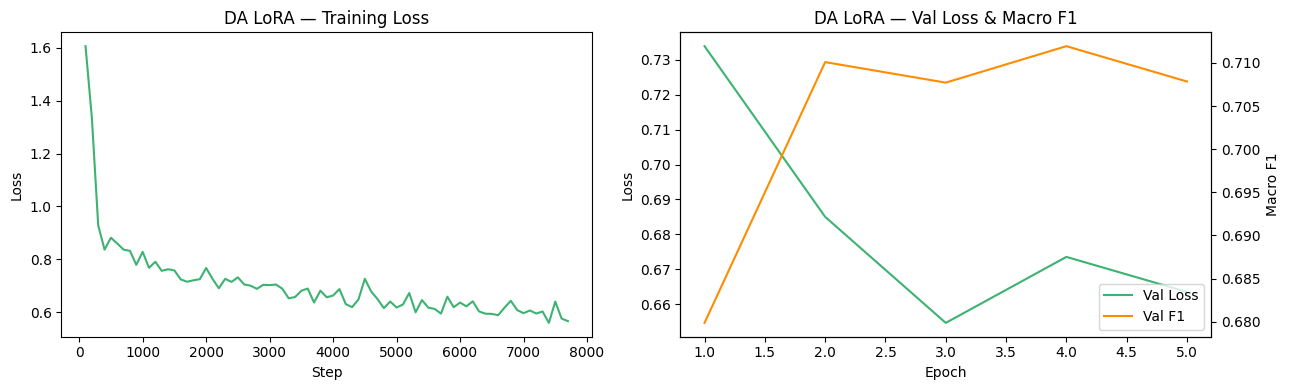

Best DA LoRA val Macro F1: 0.7119


In [42]:
DA_LORA_OUTPUT_DIR = "../models/distilroberta-domain-adapted-lora"
DA_LORA_BEST_DIR   = DA_LORA_OUTPUT_DIR + "/best"

FORCE_RETRAIN_DA_LORA = False

if not FORCE_RETRAIN_DA_LORA and os.path.exists(DA_LORA_BEST_DIR):
    print(f"Saved DA LoRA model found — skipping training.")
    base_for_load = AutoModelForSequenceClassification.from_pretrained(
        MLM_OUTPUT_DIR, num_labels=5, id2label=ID2LABEL, label2id=LABEL2ID,
        ignore_mismatched_sizes=True,
    )
    da_lora_model = PeftModel.from_pretrained(base_for_load, DA_LORA_BEST_DIR)
    da_lora_model.to(DEVICE)
else:
    da_lora_training_args = TrainingArguments(
        output_dir=DA_LORA_OUTPUT_DIR,
        num_train_epochs=5,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        learning_rate=3e-4,
        weight_decay=0.01,
        warmup_ratio=0.1,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_f1",
        greater_is_better=True,
        logging_steps=100,
        seed=SEED,
        report_to="none",
    )

    da_lora_trainer = WeightedTrainer(
        model=da_lora_model,
        args=da_lora_training_args,
        train_dataset=da_tokenized["train"],
        eval_dataset=da_tokenized["validation"],
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
        data_collator=da_collator,
    )

    da_lora_trainer.train()
    da_lora_model.save_pretrained(DA_LORA_BEST_DIR)
    da_tokenizer.save_pretrained(DA_LORA_BEST_DIR)
    print(f"DA LoRA adapters saved to '{DA_LORA_BEST_DIR}'")

    # Learning curves
    dal_log_df   = pd.DataFrame(da_lora_trainer.state.log_history)
    dal_tr_logs  = dal_log_df[dal_log_df["loss"].notna()][["step", "loss"]]
    dal_val_logs = dal_log_df[dal_log_df["eval_loss"].notna()][["epoch", "eval_loss", "eval_f1", "eval_accuracy"]]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    ax1.plot(dal_tr_logs["step"], dal_tr_logs["loss"], color="mediumseagreen")
    ax1.set(xlabel="Step", ylabel="Loss", title="DA LoRA — Training Loss")
    ax2.plot(dal_val_logs["epoch"], dal_val_logs["eval_loss"], color="mediumseagreen", label="Val Loss")
    ax2.set(xlabel="Epoch", ylabel="Loss", title="DA LoRA — Val Loss & Macro F1")
    ax2r = ax2.twinx()
    ax2r.plot(dal_val_logs["epoch"], dal_val_logs["eval_f1"], color="darkorange", label="Val F1")
    ax2r.set_ylabel("Macro F1")
    lines1, l1 = ax2.get_legend_handles_labels()
    lines2, l2 = ax2r.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, l1 + l2, loc="lower right")
    plt.tight_layout()
    plt.show()
    print(f"Best DA LoRA val Macro F1: {dal_val_logs['eval_f1'].max():.4f}")

### 13.3 Evaluation on Validation Set

Validation Set — Classification Report (DA LoRA)
               precision    recall  f1-score   support

      Neutral     0.6428    0.7324    0.6847       882
      Opinion     0.7050    0.6847    0.6947      3257
Argumentative     0.7674    0.7523    0.7598      2394
   Expressive     0.8330    0.7299    0.7781      3254
Informational     0.5290    0.8182    0.6425       770

     accuracy                         0.7277     10557
    macro avg     0.6954    0.7435    0.7119     10557
 weighted avg     0.7406    0.7277    0.7305     10557



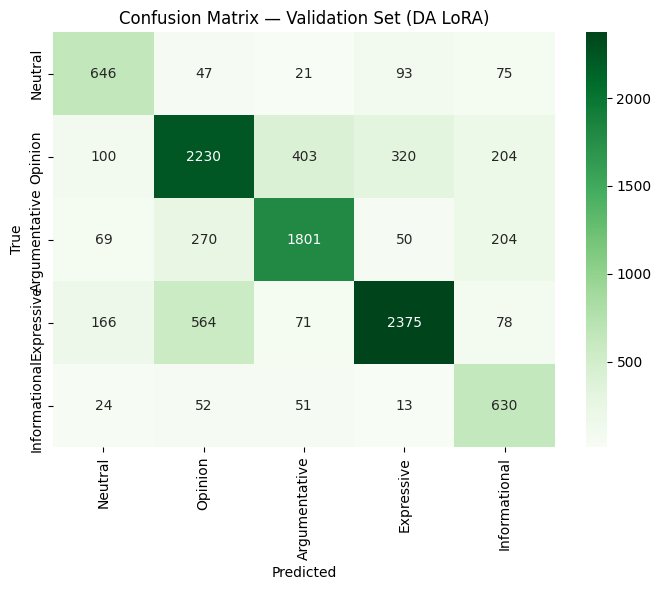

In [43]:
da_lora_trainer_eval = WeightedTrainer(
    model=da_lora_model,
    args=TrainingArguments(output_dir="/tmp/da_lora_eval", report_to="none"),
    data_collator=da_collator,
    compute_metrics=compute_metrics,
)

da_lora_val_out    = da_lora_trainer_eval.predict(da_tokenized["validation"])
da_lora_val_preds  = np.argmax(da_lora_val_out.predictions, axis=-1)
da_lora_val_labels = da_lora_val_out.label_ids

print("Validation Set — Classification Report (DA LoRA)")
print(classification_report(da_lora_val_labels, da_lora_val_preds, target_names=list(ID2LABEL.values()), digits=4))

cm = confusion_matrix(da_lora_val_labels, da_lora_val_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=list(ID2LABEL.values()),
            yticklabels=list(ID2LABEL.values()))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Validation Set (DA LoRA)")
plt.tight_layout()
plt.show()

### 13.4 Test Set Evaluation

[DA + LoRA] Test Macro F1: 0.7097 | Accuracy: 0.7270

Classification Report — DA LoRA (Test Set)
               precision    recall  f1-score   support

      Neutral     0.6246    0.7368    0.6761       779
      Opinion     0.7074    0.6822    0.6946      3257
Argumentative     0.7508    0.7573    0.7541      2423
   Expressive     0.8417    0.7291    0.7814      3289
Informational     0.5369    0.7988    0.6422       810

     accuracy                         0.7270     10558
    macro avg     0.6923    0.7409    0.7097     10558
 weighted avg     0.7400    0.7270    0.7299     10558



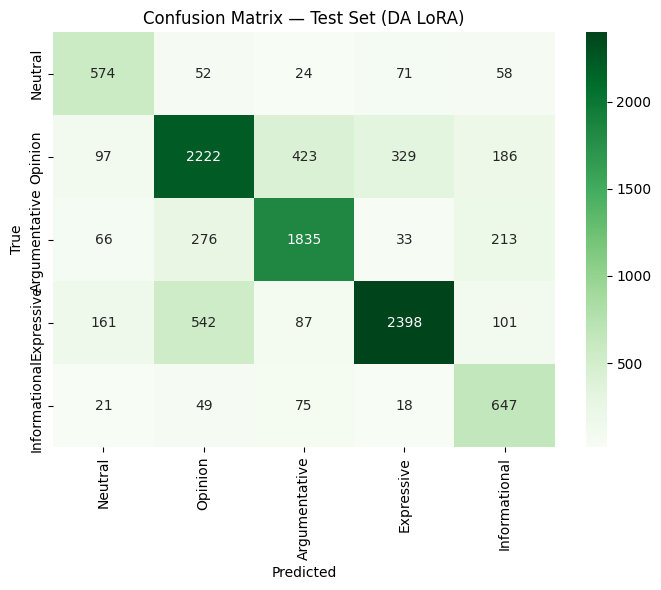

In [44]:
da_lora_test_out    = da_lora_trainer_eval.predict(da_tokenized["test"])
da_lora_test_preds  = np.argmax(da_lora_test_out.predictions, axis=-1)
da_lora_test_labels = da_lora_test_out.label_ids

da_lora_f1  = metric_f1.compute(predictions=da_lora_test_preds, references=da_lora_test_labels, average="macro")["f1"]
da_lora_acc = metric_acc.compute(predictions=da_lora_test_preds, references=da_lora_test_labels)["accuracy"]
print(f"[DA + LoRA] Test Macro F1: {da_lora_f1:.4f} | Accuracy: {da_lora_acc:.4f}")

print("\nClassification Report — DA LoRA (Test Set)")
print(classification_report(da_lora_test_labels, da_lora_test_preds, target_names=list(ID2LABEL.values()), digits=4))

cm = confusion_matrix(da_lora_test_labels, da_lora_test_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=list(ID2LABEL.values()),
            yticklabels=list(ID2LABEL.values()))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Test Set (DA LoRA)")
plt.tight_layout()
plt.show()

## 14. Final Comparison

              Model           Feature       F1  Accuracy
     Full Fine-tune        All params 0.725362  0.742375
DA + Full Fine-tune  MLM → All params 0.724995  0.741144
          DA + LoRA MLM → LoRA (r=16) 0.709657  0.727032
             LogReg             TFIDF 0.628900  0.638000
             LogReg           Hashing 0.626200  0.636100
             LogReg               BoW 0.623700  0.628300
            SVM_OvR             TFIDF 0.612900  0.618900
            SVM_OvR           Hashing 0.609300  0.618300


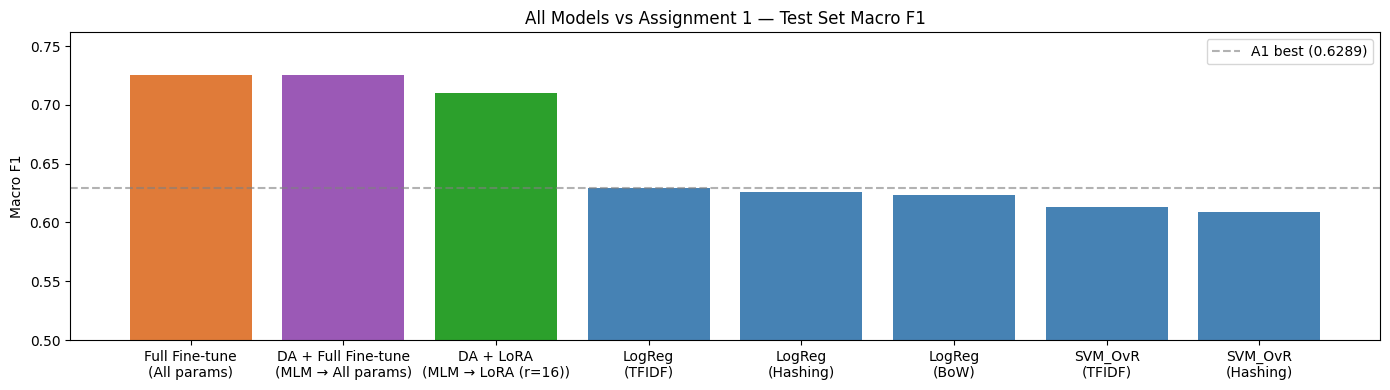

In [49]:
a1_results = pd.read_csv("pipeline_results.csv")
top_a1 = (
    a1_results.nlargest(5, "F1_Score")[["Model", "Feature", "F1_Score", "Accuracy"]]
    .rename(columns={"F1_Score": "F1"})
)

rows = [
    {"Model": "DA + LoRA",      "Feature": "MLM → LoRA (r=16)",   "F1": da_lora_f1, "Accuracy": da_lora_acc},
    {"Model": "DA + Full Fine-tune", "Feature": "MLM → All params","F1": da_f1,      "Accuracy": da_acc},
    {"Model": "Full Fine-tune",  "Feature": "All params",           "F1": test_f1,    "Accuracy": test_acc},
]
comparison_all = pd.concat([pd.DataFrame(rows), top_a1], ignore_index=True).sort_values("F1", ascending=False).reset_index(drop=True)
print(comparison_all.to_string(index=False))

a1_best_f1 = top_a1["F1"].max()
labels_bar = [f"{r['Model']}\n({r['Feature']})" for _, r in comparison_all.iterrows()]
bar_colors = [
    "#2ca02c"  if "DA + LoRA" in r["Model"]
    else "#9b59b6" if "DA + Full" in r["Model"]
    else "#e07b39" if "Full Fine" in r["Model"]
    else "steelblue"
    for _, r in comparison_all.iterrows()
]

plt.figure(figsize=(14, 4))
plt.bar(labels_bar, comparison_all["F1"], color=bar_colors)
plt.axhline(y=a1_best_f1, color="gray", linestyle="--", alpha=0.6, label=f"A1 best ({a1_best_f1:.4f})")
plt.ylabel("Macro F1")
plt.ylim(bottom=0.5)
plt.title("All Models vs Assignment 1 — Test Set Macro F1")
plt.legend()
plt.tight_layout()
plt.show()